# Used Cars Price Prediction Project

Domain: Price Prediction

Objective:
To build a machine learning model to predict the price of used cars
and identify the most important features affecting the price.

Dataset contains:
year, brand, model, distance travelled, fuel type, city, car age, price.

IMPORT LIBRARIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Load Dataset

In [15]:
df = pd.read_csv("cars.csv")
df.head()

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0


Dataset loaded successfully.
Checking structure, columns, and data types.

In [16]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       1725 non-null   int64  
 1   year                     1725 non-null   int64  
 2   brand                    1725 non-null   object 
 3   full_model_name          1725 non-null   object 
 4   model_name               1725 non-null   object 
 5   price                    1725 non-null   float64
 6   distance_travelled(kms)  1725 non-null   float64
 7   fuel_type                1725 non-null   object 
 8   city                     1725 non-null   object 
 9   brand_rank               1725 non-null   int64  
 10  car_age                  1725 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 148.4+ KB


,Id,year,price,distance_travelled(kms),brand_rank,car_age
count,1725.000000,1725.000000,1.725000e+03,1725.000000,1725.000000,1725.000000
mean,862.000000,2015.390725,1.494837e+06,53848.256232,15.731014,5.609275
std,498.108924,3.207504,1.671658e+06,44725.541963,12.951122,3.207504
min,0.000000,1990.000000,6.250000e+04,350.000000,1.000000,0.000000
25%,431.000000,2013.000000,5.450000e+05,29000.000000,5.000000,3.000000
50%,862.000000,2016.000000,8.750000e+05,49000.000000,14.000000,5.000000
75%,1293.000000,2018.000000,1.825000e+06,70500.000000,24.000000,8.000000
max,1724.000000,2021.000000,1.470000e+07,790000.000000,81.000000,31.000000


Checking for missing values in dataset


In [17]:
df.isnull().sum()

,0
Id,0
year,0
brand,0
full_model_name,0
model_name,0
price,0
distance_travelled(kms),0
fuel_type,0
city,0
brand_rank,0


UNIVARIATE ANALYSIS


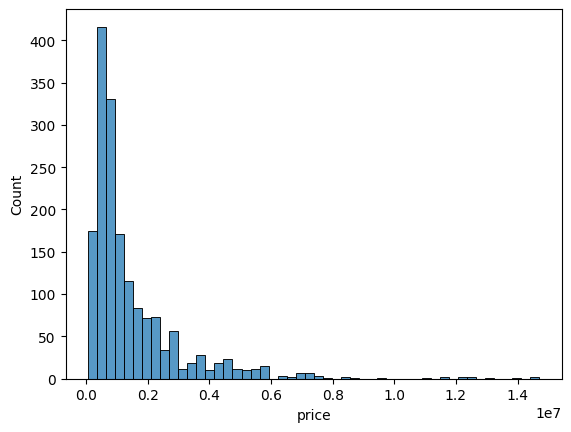

In [18]:
sns.histplot(df["price"], bins=50)
plt.show()

Distance

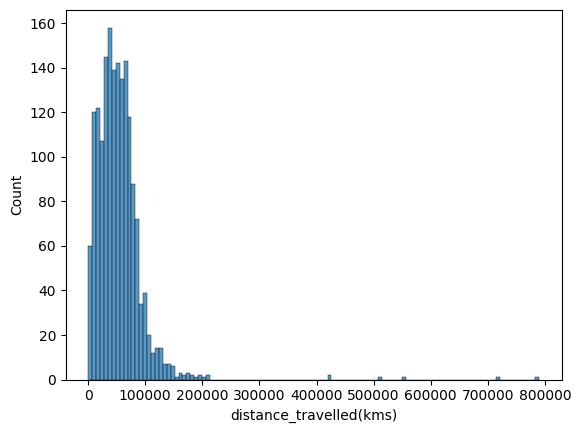

In [19]:
sns.histplot(df["distance_travelled(kms)"])
plt.show()

Fuel Type


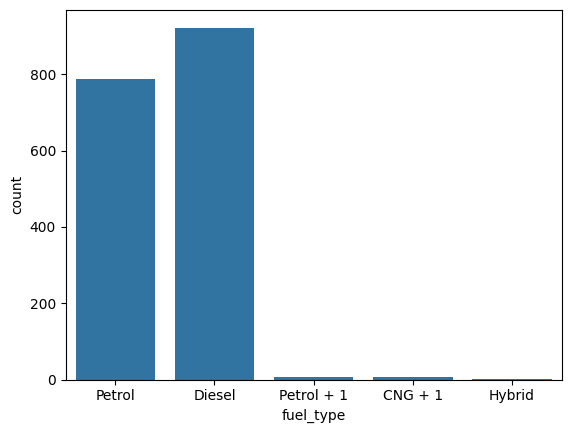

In [20]:
sns.countplot(x="fuel_type", data=df)
plt.show()

City


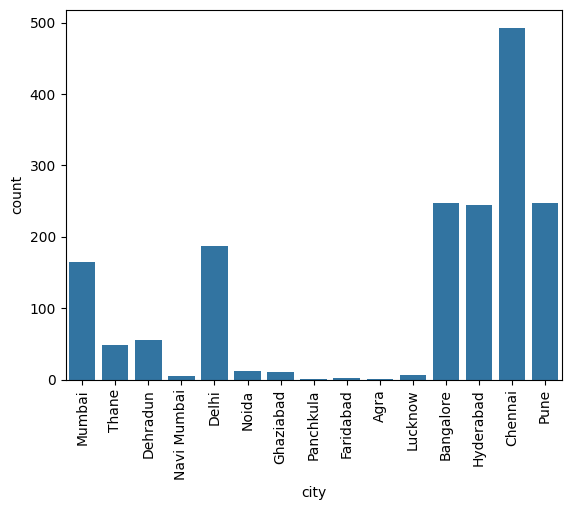

In [21]:
sns.countplot(x="city", data=df)
plt.xticks(rotation=90)
plt.show()

Univariate analysis performed to understand distribution
of important features.


MULTIVARIATE ANALYSIS TO PERFORM CORELATION


Heatmap


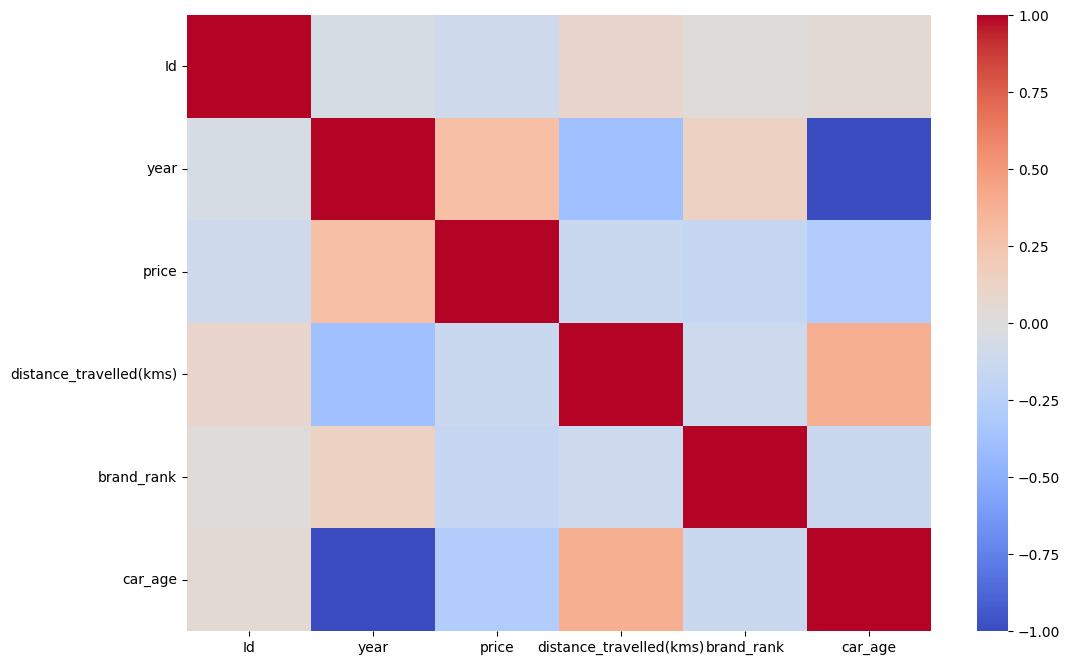

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

Relation with Price


In [23]:
df.corr(numeric_only=True)["price"].sort_values()

,price
car_age,-0.288483
brand_rank,-0.164591
distance_travelled(kms),-0.137351
Id,-0.105696
year,0.288483
price,1.000000


Correlation analysis performed to understand
relationship between features and price.


DATA CLEANING


In [24]:
df = df.drop("Id", axis=1)

Remove Id- as itnot required for analysis


In [26]:
df = df.drop("Id", axis=1, errors='ignore')

Remove null values

In [27]:
df = df.dropna()

Encoding



Data cleaned and categorical variables encoded.

In [28]:
df = pd.get_dummies(df, drop_first=True)

SPLIT DATA
Dataset split into training and testing sets.


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

LINEAR REGRESSION


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(metrics.r2_score(y_test, pred_lr))

0.744817980918479


LASSO

In [37]:
from sklearn.linear_model import Lasso
from sklearn import metrics

lasso = Lasso()
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print(metrics.r2_score(y_test, pred_lasso))

0.720069333345123


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.457e+13, tolerance: 3.651e+11
  model = cd_fast.enet_coordinate_descent(


RANDOM FOREST
Multiple regression models tested and compared.


In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(metrics.r2_score(y_test, pred_rf))

0.7089325960437999


Multiple regression models tested and compared.


In [ ]:
ChildProcessError

In [41]:
print("LR:", metrics.r2_score(y_test, pred_lr))
print("Lasso:", metrics.r2_score(y_test, pred_lasso))
print("RF:", metrics.r2_score(y_test, pred_rf))

LR: 0.744817980918479
Lasso: 0.720069333345123
RF: 0.7089325960437999


IMPORTANT FEATURES


In [42]:
feat = pd.Series(rf.feature_importances_, index=X.columns)
feat.sort_values().tail(10)

,0
brand_Volvo,0.028523
full_model_name_Mercedes-Benz S-Class S 63 AMG,0.028776
brand_BMW,0.029744
distance_travelled(kms),0.038185
brand_Jaguar,0.039033
brand_Land Rover,0.040041
brand_Mercedes-Benz,0.046917
year,0.068561
car_age,0.081754
brand_rank,0.118623


Random Forest gave best performance.
Most important features affecting price:
- car_age
- distance_travelled
- brand
- city

Model successfully predicts used car price.
